## PolypDB Dataset

**PolypDB** is a multi-modality endoscopic polyp dataset designed for polyp segmentation and analysis. It contains endoscopic images acquired using different imaging modalities.

### Imaging Modalities

| Modality | Full Form | Description |
|---|---|---|
| **NBI** | Narrow Band Imaging | Uses narrow bands of blue and green light to enhance mucosal microvascular patterns making  boundary details more prominent. |
| **FICE** | Flexible Spectral Imaging Color Enhancement | A spectral image-processing technique that reconstructs specific wavelengths to enhance mucosal structures and vascular patterns. |
| **LCI** | Linked Color Imaging | Enhances color differences between the mucosa and lesions, improving the visual contrast of polyps and surrounding tissue. |
| **BLI** | Blue Light Imaging | Uses short-wavelength blue/violet illumination to emphasize fine surface structures and microvascular patterns of lesions. |
| **WLI** | White Light Imaging | Standard endoscopic imaging using conventional white illumination. It provides the most natural appearance of the mucosa and polyps. |

### Why Multiple Modalities?

The different modalities highlight different characteristics of a polyp:

- **NBI** → Vascular and mucosal microstructures
- **FICE** → Spectral and surface feature enhancement
- **LCI** → Color and lesion-to-background contrast
- **BLI** → Fine surface and vascular patterns
- **WLI** → Natural appearance and overall anatomical context

Therefore, PolypDB provides a useful benchmark for evaluating the **robustness and generalization of polyp segmentation models across different endoscopic imaging conditions**.


FICE
Images       : 70
Masks        : 70
Valid pairs  : 70

NBI
Images       : 146
Masks        : 146
Valid pairs  : 146

LCI
Images       : 60
Masks        : 60
Valid pairs  : 60

BLI
Images       : 70
Masks        : 70
Valid pairs  : 70


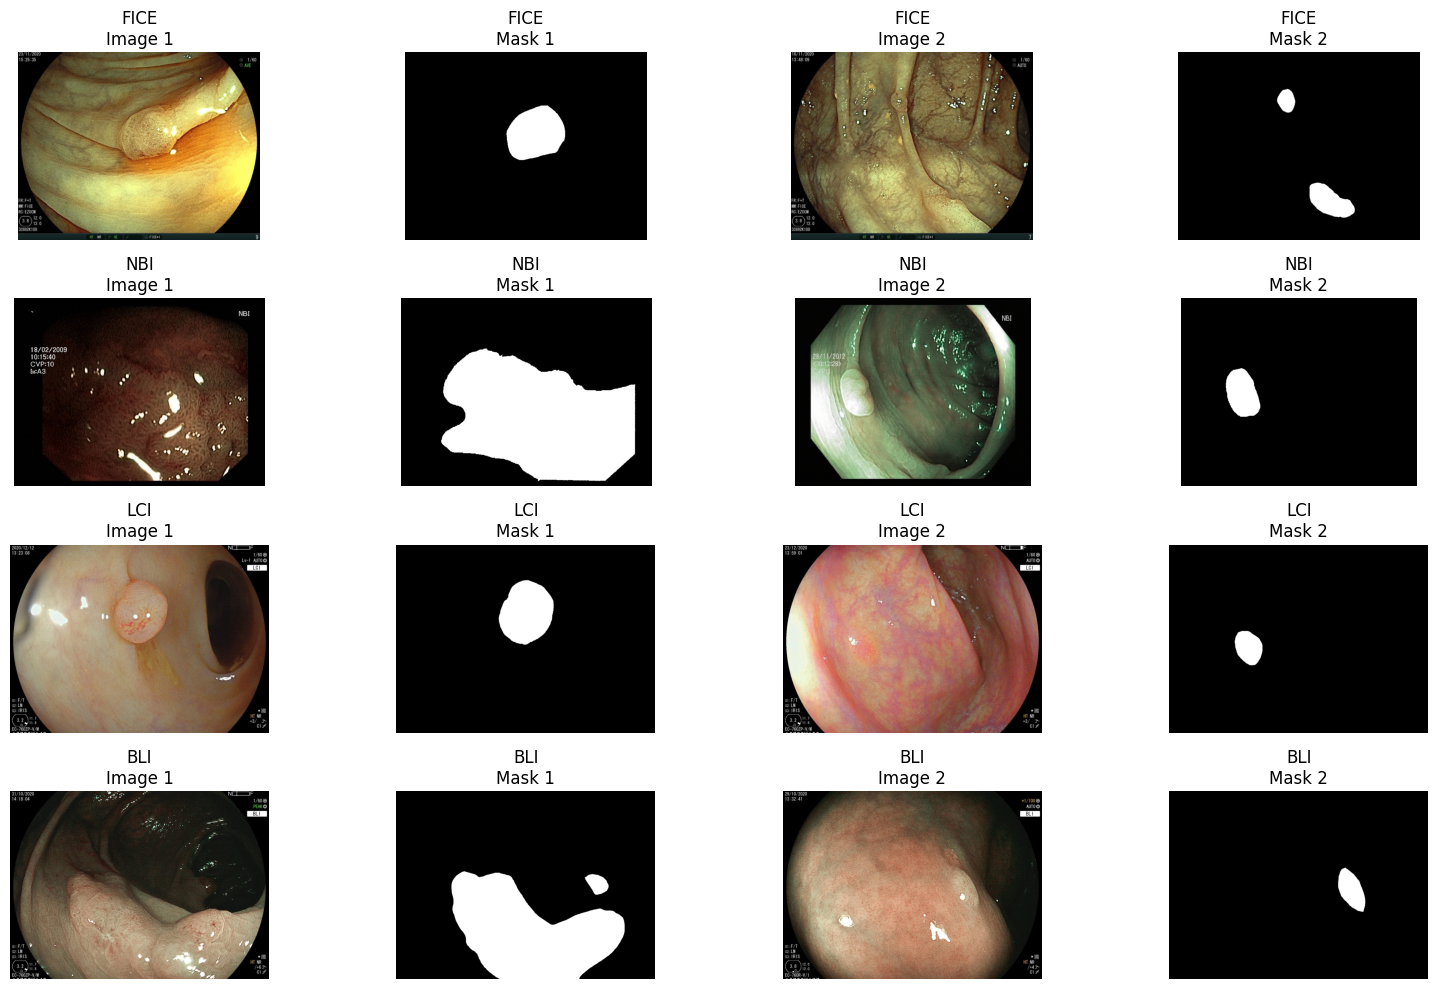

In [ ]:
# Visualize Few Samples From PolypDB
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

base_path = "/kaggle/input/datasets/shivanshuagnihotri/polypdb-official/PolypDB/PolypDB/PolypDB_modality_wise"

modalities = ["FICE", "NBI", "LCI", "BLI"]
num_samples = 2

fig, axes = plt.subplots(
    len(modalities),
    num_samples * 2,
    figsize=(16, 10)
)

for row, modality in enumerate(modalities):

    image_dir = os.path.join(base_path, modality, "images")
    mask_dir = os.path.join(base_path, modality, "masks")

    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    mask_files = [
        f for f in os.listdir(mask_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    # Map mask filename stem -> actual mask filename
    mask_dict = {
        os.path.splitext(f)[0]: f
        for f in mask_files
    }

    # Find images having corresponding masks
    valid_pairs = []

    for image_file in image_files:
        image_stem = os.path.splitext(image_file)[0]

        if image_stem in mask_dict:
            valid_pairs.append(
                (image_file, mask_dict[image_stem])
            )

    print(f"\n{modality}")
    print(f"Images       : {len(image_files)}")
    print(f"Masks        : {len(mask_files)}")
    print(f"Valid pairs  : {len(valid_pairs)}")

    if len(valid_pairs) == 0:
        print("No matching image-mask pairs found!")
        continue

    samples = random.sample(
        valid_pairs,
        min(num_samples, len(valid_pairs))
    )

    for i, (image_file, mask_file) in enumerate(samples):

        image_path = os.path.join(image_dir, image_file)
        mask_path = os.path.join(mask_dir, mask_file)

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Image
        axes[row, i * 2].imshow(image)
        axes[row, i * 2].set_title(
            f"{modality}\nImage {i+1}"
        )
        axes[row, i * 2].axis("off")

        # Mask
        axes[row, i * 2 + 1].imshow(mask, cmap="gray")
        axes[row, i * 2 + 1].set_title(
            f"{modality}\nMask {i+1}"
        )
        axes[row, i * 2 + 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Data Augmentation For PolypDB

import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
import imageio
from albumentations import (
    HorizontalFlip, VerticalFlip, Rotate, RandomBrightnessContrast,
    GaussianBlur, ShiftScaleRotate
)

def create_dir(path):
    """Create a directory if it does not exist."""
    if not os.path.exists(path):
        os.makedirs(path)

def load_data(modality_path):
    """Load the dataset paths for images and masks from each modality."""
    image_exts = ["*.jpg", "*.png"]  # Check for both .jpg and .png
    mask_exts = ["*.png", "*.jpg"]  # Mask files can also have mixed extensions

    images = []
    masks = []

    # Collect all image files (.jpg and .png)
    for ext in image_exts:
        images.extend(sorted(glob(os.path.join(modality_path, "images", ext))))

    # Collect all mask files (.png and .jpg)
    for ext in mask_exts:
        masks.extend(sorted(glob(os.path.join(modality_path, "masks", ext))))

    return images, masks

def augment_data(images, masks, save_path, augment=True, num_augments=10):
    """Augment the data and save it to the specified path."""
    size = (512, 512)  # Target size for saving the images and masks
    for idx, (x, y) in tqdm(enumerate(zip(images, masks)), total=len(images)):
        """Extracting the name"""
        name = x.split("/")[-1].split(".")[0]

        """Reading image and mask"""
        x = cv2.imread(x, cv2.IMREAD_COLOR)
        y = imageio.imread(y)

        # Check if images and masks are properly loaded
        if x is None or y is None:
            print(f"Failed to load image or mask: {name}")
            continue

        """Saving the original image and mask"""
        x_orig = cv2.resize(x, size)
        y_orig = cv2.resize(y, size)

        original_image_name = f"{name}_orig.png"
        original_mask_name = f"{name}_orig.png"

        cv2.imwrite(os.path.join(save_path, "image", original_image_name), x_orig)
        cv2.imwrite(os.path.join(save_path, "mask", original_mask_name), y_orig)

        """Augmentations"""
        for i in range(num_augments):
            if augment:
                """Applying multiple augmentations"""
                aug = HorizontalFlip(p=0.5)
                augmented = aug(image=x, mask=y)
                x1 = augmented["image"]
                y1 = augmented["mask"]

                aug = VerticalFlip(p=0.5)
                augmented = aug(image=x1, mask=y1)
                x2 = augmented["image"]
                y2 = augmented["mask"]

                aug = Rotate(limit=45, p=0.7)
                augmented = aug(image=x2, mask=y2)
                x3 = augmented["image"]
                y3 = augmented["mask"]

                aug = RandomBrightnessContrast(p=0.5)
                augmented = aug(image=x3, mask=y3)
                x4 = augmented["image"]
                y4 = augmented["mask"]

                aug = GaussianBlur(p=0.3)
                augmented = aug(image=x4, mask=y4)
                x5 = augmented["image"]
                y5 = augmented["mask"]

                aug = ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5)
                augmented = aug(image=x5, mask=y5)
                x6 = augmented["image"]
                y6 = augmented["mask"]

                """Saving the augmented images and masks"""
                x_aug = cv2.resize(x6, size)
                y_aug = cv2.resize(y6, size)

                augmented_image_name = f"{name}_aug_{i}.png"
                augmented_mask_name = f"{name}_aug_{i}.png"

                cv2.imwrite(os.path.join(save_path, "image", augmented_image_name), x_aug)
                cv2.imwrite(os.path.join(save_path, "mask", augmented_mask_name), y_aug)

if __name__ == "__main__":
    """Seeding"""
    np.random.seed(42)

    """Path to the PolypDB dataset"""
    base_path = "/kaggle/input/polypdb-official/PolypDB/PolypDB/PolypDB_modality_wise"
    modalities = ["BLI", "FICE", "LCI", "NBI"]

    for modality in modalities:
        modality_path = os.path.join(base_path, modality)

        """Load the data for each modality"""
        images, masks = load_data(modality_path)
        print(f"{modality} - Images: {len(images)} - Masks: {len(masks)}")

        """Create directories to save the augmented data"""
        save_path = f"/kaggle/working/augmented_data/{modality}/"
        create_dir(os.path.join(save_path, "image"))
        create_dir(os.path.join(save_path, "mask"))

        """Apply augmentation and save"""
        augment_data(images, masks, save_path, augment=True, num_augments=10)  # Generate 10 augmentations per image


/opt/conda/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.18 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


BLI - Images: 70 - Masks: 70


  0%|          | 0/70 [00:00<?, ?it/s]/tmp/ipykernel_30/351916025.py:46: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  y = imageio.imread(y)
100%|██████████| 70/70 [00:47<00:00,  1.47it/s]


FICE - Images: 70 - Masks: 70


100%|██████████| 70/70 [00:50<00:00,  1.39it/s]


LCI - Images: 60 - Masks: 60


100%|██████████| 60/60 [00:41<00:00,  1.45it/s]


NBI - Images: 146 - Masks: 146


100%|██████████| 146/146 [01:15<00:00,  1.92it/s]


In [ ]:
!pip install ptflops
import torch
import torch.nn as nn

class Squeeze_Excitation(nn.Module):
    def __init__(self, channel, r=8):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.net = nn.Sequential(
            nn.Linear(channel, channel // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // r, channel, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, inputs):
        b, c, _, _ = inputs.shape
        x = self.pool(inputs).view(b, c)
        x = self.net(x).view(b, c, 1, 1)
        x = inputs * x
        return x

class Stem_Block(nn.Module):
    def __init__(self, in_c, out_c, stride):
        super().__init__()

        self.c1 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
        )

        self.c2 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, padding=0),
            nn.BatchNorm2d(out_c),
        )

        self.attn = Squeeze_Excitation(out_c)

    def forward(self, inputs):
        x = self.c1(inputs)
        s = self.c2(inputs)
        y = self.attn(x + s)
        return y

class ResNet_Block(nn.Module):
    def __init__(self, in_c, out_c, stride):
        super().__init__()

        self.c1 = nn.Sequential(
            nn.BatchNorm2d(in_c),
            nn.ReLU(),
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, stride=stride),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        )

        self.c2 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, padding=0),
            nn.BatchNorm2d(out_c),
        )

        self.attn = Squeeze_Excitation(out_c)

    def forward(self, inputs):
        x = self.c1(inputs)
        s = self.c2(inputs)
        y = self.attn(x + s)
        return y

class ASPP(nn.Module):
    def __init__(self, in_c, out_c, rate=[1, 6, 12, 18]):
        super().__init__()

        self.c1 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, dilation=rate[0], padding=rate[0]),
            nn.BatchNorm2d(out_c)
        )

        self.c2 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, dilation=rate[1], padding=rate[1]),
            nn.BatchNorm2d(out_c)
        )

        self.c3 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, dilation=rate[2], padding=rate[2]),
            nn.BatchNorm2d(out_c)
        )

        self.c4 = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, dilation=rate[3], padding=rate[3]),
            nn.BatchNorm2d(out_c)
        )

        self.c5 = nn.Conv2d(out_c, out_c, kernel_size=1, padding=0)


    def forward(self, inputs):
        x1 = self.c1(inputs)
        x2 = self.c2(inputs)
        x3 = self.c3(inputs)
        x4 = self.c4(inputs)
        x = x1 + x2 + x3 + x4
        y = self.c5(x)
        return y

class Attention_Block(nn.Module):
    def __init__(self, in_c):
        super().__init__()
        out_c = in_c[1]

        self.g_conv = nn.Sequential(
            nn.BatchNorm2d(in_c[0]),
            nn.ReLU(),
            nn.Conv2d(in_c[0], out_c, kernel_size=3, padding=1),
            nn.MaxPool2d((2, 2))
        )

        self.x_conv = nn.Sequential(
            nn.BatchNorm2d(in_c[1]),
            nn.ReLU(),
            nn.Conv2d(in_c[1], out_c, kernel_size=3, padding=1),
        )

        self.gc_conv = nn.Sequential(
            nn.BatchNorm2d(in_c[1]),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
        )

    def forward(self, g, x):
        g_pool = self.g_conv(g)
        x_conv = self.x_conv(x)
        gc_sum = g_pool + x_conv
        gc_conv = self.gc_conv(gc_sum)
        y = gc_conv * x
        return y

class Decoder_Block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.a1 = Attention_Block(in_c)
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.r1 = ResNet_Block(in_c[0]+in_c[1], out_c, stride=1)

    def forward(self, g, x):
        d = self.a1(g, x)
        d = self.up(d)
        d = torch.cat([d, g], axis=1)
        d = self.r1(d)
        return d

class build_resunetplusplus(nn.Module):
    def __init__(self):
        super().__init__()

        self.c1 = Stem_Block(3, 16, stride=1)
        self.c2 = ResNet_Block(16, 32, stride=2)
        self.c3 = ResNet_Block(32, 64, stride=2)
        self.c4 = ResNet_Block(64, 128, stride=2)

        self.b1 = ASPP(128, 256)

        self.d1 = Decoder_Block([64, 256], 128)
        self.d2 = Decoder_Block([32, 128], 64)
        self.d3 = Decoder_Block([16, 64], 32)

        self.aspp = ASPP(32, 16)
        self.output = nn.Conv2d(16, 1, kernel_size=1, padding=0)

    def forward(self, inputs):
        c1 = self.c1(inputs)
        c2 = self.c2(c1)
        c3 = self.c3(c2)
        c4 = self.c4(c3)

        b1 = self.b1(c4)

        d1 = self.d1(c3, b1)
        d2 = self.d2(c2, d1)
        d3 = self.d3(c1, d2)

        output = self.aspp(d3)
        output = self.output(output)

        return output


if __name__ == "__main__":
    model = build_resunetplusplus()
    from ptflops import get_model_complexity_info
    flops, params = get_model_complexity_info(model, input_res=(3, 256, 256), as_strings=True, print_per_layer_stat=False)
    print('      - Flops:  ' + flops)
    print('      - Params: ' + params)

      - Flops:  15.85 GMac
      - Params: 4.06 M


In [ ]:
#Metrics
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.spatial.distance import directed_hausdorff

""" Loss Functions -------------------------------------- """
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)

        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)

        return 1 - dice

class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)

        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        Dice_BCE = BCE + dice_loss

        return Dice_BCE

""" Metrics ------------------------------------------ """
def precision(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    return (intersection + 1e-15) / (y_pred.sum() + 1e-15)

def recall(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    return (intersection + 1e-15) / (y_true.sum() + 1e-15)

def F2(y_true, y_pred, beta=2):
    p = precision(y_true,y_pred)
    r = recall(y_true, y_pred)
    return (1+beta**2.) *(p*r) / float(beta**2*p + r + 1e-15)

def dice_score(y_true, y_pred):
    return (2 * (y_true * y_pred).sum() + 1e-15) / (y_true.sum() + y_pred.sum() + 1e-15)

def jac_score(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    union = y_true.sum() + y_pred.sum() - intersection
    return (intersection + 1e-15) / (union + 1e-15)

## https://www.kaggle.com/competitions/uw-madison-gi-tract-image-segmentation/discussion/319452
def hd_dist(preds, targets):
    haussdorf_dist = directed_hausdorff(preds, targets)[0]
    return haussdorf_dist

In [ ]:
#Utills
import os
import random
import numpy as np
import cv2
from tqdm import tqdm
import torch
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, confusion_matrix

""" Seeding the randomness. """
def seeding(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

""" Create a directory """
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

""" Shuffle the dataset. """
def shuffling(x, y):
    x, y = shuffle(x, y, random_state=42)
    return x, y

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def print_and_save(file_path, data_str):
    print(data_str)
    with open(file_path, "a") as file:
        file.write(data_str)
        file.write("\n")

def calculate_metrics(y_true, y_pred):
    ## Tensor processing
    y_true = y_true.detach().cpu().numpy()
    y_pred = y_pred.detach().cpu().numpy()

    y_pred = y_pred > 0.5
    y_pred = y_pred.astype(np.uint8)

    y_true = y_true > 0.5
    y_true = y_true.astype(np.uint8)

    ## HD
    if len(y_true.shape) == 3:
        score_hd = hd_dist(y_true[0], y_pred[0])
    elif len(y_true.shape) == 4:
        score_hd = hd_dist(y_true[0,0], y_pred[0,0])

    ## Reshape
    y_pred = y_pred.reshape(-1)
    y_true = y_true.reshape(-1)

    ## Score
    score_jaccard = jac_score(y_true, y_pred)
    score_f1 = dice_score(y_true, y_pred)
    score_recall = recall(y_true, y_pred)
    score_precision = precision(y_true, y_pred)
    score_fbeta = F2(y_true, y_pred)
    score_acc = accuracy_score(y_true, y_pred)

    return [score_jaccard, score_f1, score_recall, score_precision, score_acc, score_fbeta, score_hd]

In [ ]:
#Train for 4 modalities NBI, LCI, FICE and BLI

import os
import time
import datetime
import numpy as np
import cv2
from glob import glob
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

def load_augmented_data(path):
    """ Load augmented images and masks from the given path. """
    def get_data(path):
        images = sorted(glob(os.path.join(path, "image", "*.png")))
        masks = sorted(glob(os.path.join(path, "mask", "*.png")))
        return images, masks

    """ Load all data """
    images, masks = get_data(path)

    """ First split to get 88% for training and validation and 12% for testing """
    train_val_x, test_x, train_val_y, test_y = train_test_split(images, masks, test_size=0.12, random_state=42)

    """ Then split the 88% data into 80% training and 8% validation (90.9%/9.1% split of 88%) """
    train_x, valid_x, train_y, valid_y = train_test_split(train_val_x, train_val_y, test_size=0.0909, random_state=42)

    return [(train_x, train_y), (valid_x, valid_y), (test_x, test_y)]

class DATASET(Dataset):
    def __init__(self, images_path, masks_path, size):
        super().__init__()

        self.images_path = images_path
        self.masks_path = masks_path
        self.size = size
        self.n_samples = len(images_path)

    def __getitem__(self, index):
        """ Image """
        image = cv2.imread(self.images_path[index], cv2.IMREAD_COLOR)
        mask = cv2.imread(self.masks_path[index], cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, self.size)
        image = np.transpose(image, (2, 0, 1))
        image = image / 255.0

        mask = cv2.resize(mask, self.size)
        mask = np.expand_dims(mask, axis=0)
        mask = mask / 255.0

        return image, mask

    def __len__(self):
        return self.n_samples

def train(model, loader, optimizer, loss_fn, device):
    model.train()

    epoch_loss = 0.0
    epoch_jac = 0.0
    epoch_f1 = 0.0
    epoch_recall = 0.0
    epoch_precision = 0.0

    for i, (x, y) in enumerate(loader):
        x = x.to(device, dtype=torch.float32)
        y = y.to(device, dtype=torch.float32)

        optimizer.zero_grad()
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        """ Calculate the metrics """
        batch_jac = []
        batch_f1 = []
        batch_recall = []
        batch_precision = []

        y_pred = torch.sigmoid(y_pred)
        for yt, yp in zip(y, y_pred):
            score = calculate_metrics(yt, yp)
            batch_jac.append(score[0])
            batch_f1.append(score[1])
            batch_recall.append(score[2])
            batch_precision.append(score[3])

        epoch_jac += np.mean(batch_jac)
        epoch_f1 += np.mean(batch_f1)
        epoch_recall += np.mean(batch_recall)
        epoch_precision += np.mean(batch_precision)

    epoch_loss = epoch_loss / len(loader)
    epoch_jac = epoch_jac / len(loader)
    epoch_f1 = epoch_f1 / len(loader)
    epoch_recall = epoch_recall / len(loader)
    epoch_precision = epoch_precision / len(loader)

    return epoch_loss, [epoch_jac, epoch_f1, epoch_recall, epoch_precision]

def evaluate(model, loader, loss_fn, device):
    model.eval()

    epoch_loss = 0.0
    epoch_jac = 0.0
    epoch_f1 = 0.0
    epoch_recall = 0.0
    epoch_precision = 0.0

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x = x.to(device, dtype=torch.float32)
            y = y.to(device, dtype=torch.float32)

            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            epoch_loss += loss.item()

            """ Calculate the metrics """
            batch_jac = []
            batch_f1 = []
            batch_recall = []
            batch_precision = []

            y_pred = torch.sigmoid(y_pred)
            for yt, yp in zip(y, y_pred):
                score = calculate_metrics(yt, yp)
                batch_jac.append(score[0])
                batch_f1.append(score[1])
                batch_recall.append(score[2])
                batch_precision.append(score[3])

            epoch_jac += np.mean(batch_jac)
            epoch_f1 += np.mean(batch_f1)
            epoch_recall += np.mean(batch_recall)
            epoch_precision += np.mean(batch_precision)

    epoch_loss = epoch_loss / len(loader)
    epoch_jac = epoch_jac / len(loader)
    epoch_f1 = epoch_f1 / len(loader)
    epoch_recall = epoch_recall / len(loader)
    epoch_precision = epoch_precision / len(loader)

    return epoch_loss, [epoch_jac, epoch_f1, epoch_recall, epoch_precision]

if __name__ == "__main__":
    """ Seeding """
    np.random.seed(42)

    """ Directories """
    create_dir("files")

    """ Training logfile """
    train_log_path = "files/train_log.txt"
    if not os.path.exists(train_log_path):
        train_log = open(train_log_path, "w")
        train_log.write("\n")
        train_log.close()

    """ Hyperparameters """
    image_size = 256
    size = (image_size, image_size)
    batch_size = 8
    num_epochs = 80
    lr = 1e-4
    early_stopping_patience = 50

    modalities = ["NBI", "LCI", "FICE", "BLI"]

    for modality in modalities:
        print(f"\nTraining for modality: {modality}")

        """ Set the augmented data path for the current modality """
        augmented_data_path = f"/kaggle/working/augmented_data/{modality}"

        """ Log the current modality """
        print_and_save(train_log_path, f"\n### Training for modality: {modality} ###\n")

        """ Dataset """
        (train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_augmented_data(augmented_data_path)
        train_x, train_y = shuffling(train_x, train_y)

        data_str = f"Dataset Size for {modality}:\nTrain: {len(train_x)} - Valid: {len(valid_x)} - Test: {len(test_x)}\n"
        print_and_save(train_log_path, data_str)

        """ Dataset and loader """
        train_dataset = DATASET(train_x, train_y, size)
        valid_dataset = DATASET(valid_x, valid_y, size)

        train_loader = DataLoader(
            dataset=train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=2
        )

        valid_loader = DataLoader(
            dataset=valid_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=2
        )

        """ Model """
        device = torch.device('cuda')
        model = build_resunetplusplus()
        model = model.to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, verbose=True)
        loss_fn = DiceBCELoss()
        loss_name = "BCE Dice Loss"
        data_str = f"Optimizer: Adam\nLoss: {loss_name}\n"
        print_and_save(train_log_path, data_str)

        """ Save checkpoint for each modality """
        modality_checkpoint_path = f"files/{modality}_checkpoint.pth"

        """ Training the model """
        best_valid_metrics = 0.0
        early_stopping_count = 0

        for epoch in range(num_epochs):
            start_time = time.time()

            train_loss, train_metrics = train(model, train_loader, optimizer, loss_fn, device)
            valid_loss, valid_metrics = evaluate(model, valid_loader, loss_fn, device)
            scheduler.step(valid_loss)

            if valid_metrics[1] > best_valid_metrics:
                data_str = f"Valid F1 improved from {best_valid_metrics:2.4f} to {valid_metrics[1]:2.4f}. Saving checkpoint: {modality_checkpoint_path}"
                print_and_save(train_log_path, data_str)

                best_valid_metrics = valid_metrics[1]
                torch.save(model.state_dict(), modality_checkpoint_path)
                early_stopping_count = 0

            elif valid_metrics[1] < best_valid_metrics:
                early_stopping_count += 1

            end_time = time.time()
            epoch_mins, epoch_secs = epoch_time(start_time, end_time)

            data_str = f"Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s\n"
            data_str += f"\tTrain Loss: {train_loss:.4f} - Train Jaccard: {train_metrics[0]:.4f} - Train F1: {train_metrics[1]:.4f}\n"
            data_str += f"\tValid Loss: {valid_loss:.4f} - Valid Jaccard: {valid_metrics[0]:.4f} - Valid F1: {valid_metrics[1]:.4f}\n"
            print_and_save(train_log_path, data_str)

            if early_stopping_count == early_stopping_patience:
                data_str = "Early stopping triggered!"
                print_and_save(train_log_path, data_str)
                break

        print(f"Training for modality {modality} completed!\n")



Training for modality: NBI

### Training for modality: NBI ###

Dataset Size for NBI:
Train: 1392 - Valid: 140 - Test: 210

Optimizer: Adam
Loss: BCE Dice Loss



/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Valid F1 improved from 0.0000 to 0.3856. Saving checkpoint: files/NBI_checkpoint.pth
Epoch: 01 | Epoch Time: 0m 49s
	Train Loss: 1.4324 - Train Jaccard: 0.2174 - Train F1: 0.3186
	Valid Loss: 1.3243 - Valid Jaccard: 0.2707 - Valid F1: 0.3856

Valid F1 improved from 0.3856 to 0.3954. Saving checkpoint: files/NBI_checkpoint.pth
Epoch: 02 | Epoch Time: 0m 47s
	Train Loss: 1.4368 - Train Jaccard: 0.2621 - Train F1: 0.3737
	Valid Loss: 1.4788 - Valid Jaccard: 0.2847 - Valid F1: 0.3954

Valid F1 improved from 0.3954 to 0.4396. Saving checkpoint: files/NBI_checkpoint.pth
Epoch: 03 | Epoch Time: 0m 47s
	Train Loss: 1.3473 - Train Jaccard: 0.2810 - Train F1: 0.3934
	Valid Loss: 1.2649 - Valid Jaccard: 0.3184 - Valid F1: 0.4396

Epoch: 04 | Epoch Time: 0m 47s
	Train Loss: 1.2176 - Train Jaccard: 0.3033 - Train F1: 0.4174
	Valid Loss: 1.7948 - Valid Jaccard: 0.2745 - Valid F1: 0.3794

Epoch: 05 | Epoch Time: 0m 46s
	Train Loss: 1.0371 - Train Jaccard: 0.3180 - Train F1: 0.4318
	Valid Loss: 1.0214

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Valid F1 improved from 0.0000 to 0.1030. Saving checkpoint: files/LCI_checkpoint.pth
Epoch: 01 | Epoch Time: 0m 23s
	Train Loss: 1.6146 - Train Jaccard: 0.0611 - Train F1: 0.1074
	Valid Loss: 1.6006 - Valid Jaccard: 0.0588 - Valid F1: 0.1030

Valid F1 improved from 0.1030 to 0.1358. Saving checkpoint: files/LCI_checkpoint.pth
Epoch: 02 | Epoch Time: 0m 20s
	Train Loss: 1.5750 - Train Jaccard: 0.0706 - Train F1: 0.1208
	Valid Loss: 1.5817 - Valid Jaccard: 0.0798 - Valid F1: 0.1358

Valid F1 improved from 0.1358 to 0.2311. Saving checkpoint: files/LCI_checkpoint.pth
Epoch: 03 | Epoch Time: 0m 19s
	Train Loss: 1.5277 - Train Jaccard: 0.0995 - Train F1: 0.1641
	Valid Loss: 1.4873 - Valid Jaccard: 0.1469 - Valid F1: 0.2311

Epoch: 04 | Epoch Time: 0m 19s
	Train Loss: 1.4707 - Train Jaccard: 0.1259 - Train F1: 0.1999
	Valid Loss: 1.4285 - Valid Jaccard: 0.1323 - Valid F1: 0.2146

Valid F1 improved from 0.2311 to 0.2722. Saving checkpoint: files/LCI_checkpoint.pth
Epoch: 05 | Epoch Time: 0m 1

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Valid F1 improved from 0.0000 to 0.1725. Saving checkpoint: files/FICE_checkpoint.pth
Epoch: 01 | Epoch Time: 0m 26s
	Train Loss: 1.6346 - Train Jaccard: 0.0791 - Train F1: 0.1394
	Valid Loss: 2.2315 - Valid Jaccard: 0.1011 - Valid F1: 0.1725

Valid F1 improved from 0.1725 to 0.2719. Saving checkpoint: files/FICE_checkpoint.pth
Epoch: 02 | Epoch Time: 0m 23s
	Train Loss: 1.5803 - Train Jaccard: 0.1255 - Train F1: 0.2082
	Valid Loss: 1.7441 - Valid Jaccard: 0.1762 - Valid F1: 0.2719

Valid F1 improved from 0.2719 to 0.2974. Saving checkpoint: files/FICE_checkpoint.pth
Epoch: 03 | Epoch Time: 0m 22s
	Train Loss: 1.5362 - Train Jaccard: 0.1545 - Train F1: 0.2493
	Valid Loss: 2.1685 - Valid Jaccard: 0.2034 - Valid F1: 0.2974

Valid F1 improved from 0.2974 to 0.3211. Saving checkpoint: files/FICE_checkpoint.pth
Epoch: 04 | Epoch Time: 0m 22s
	Train Loss: 1.4811 - Train Jaccard: 0.1758 - Train F1: 0.2776
	Valid Loss: 1.9946 - Valid Jaccard: 0.2123 - Valid F1: 0.3211

Epoch: 05 | Epoch Time: 

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Valid F1 improved from 0.0000 to 0.0096. Saving checkpoint: files/BLI_checkpoint.pth
Epoch: 01 | Epoch Time: 0m 22s
	Train Loss: 1.4575 - Train Jaccard: 0.0135 - Train F1: 0.0226
	Valid Loss: 1.6781 - Valid Jaccard: 0.0054 - Valid F1: 0.0096

Epoch: 02 | Epoch Time: 0m 22s
	Train Loss: 1.4206 - Train Jaccard: 0.0137 - Train F1: 0.0215
	Valid Loss: 1.4298 - Valid Jaccard: 0.0042 - Valid F1: 0.0065

Valid F1 improved from 0.0096 to 0.0245. Saving checkpoint: files/BLI_checkpoint.pth
Epoch: 03 | Epoch Time: 0m 22s
	Train Loss: 1.3849 - Train Jaccard: 0.0324 - Train F1: 0.0486
	Valid Loss: 1.4751 - Valid Jaccard: 0.0145 - Valid F1: 0.0245

Valid F1 improved from 0.0245 to 0.0536. Saving checkpoint: files/BLI_checkpoint.pth
Epoch: 04 | Epoch Time: 0m 22s
	Train Loss: 1.3450 - Train Jaccard: 0.0394 - Train F1: 0.0593
	Valid Loss: 1.3654 - Valid Jaccard: 0.0334 - Valid F1: 0.0536

Valid F1 improved from 0.0536 to 0.0585. Saving checkpoint: files/BLI_checkpoint.pth
Epoch: 05 | Epoch Time: 0m 2

In [ ]:
#test for 4 modalaties
import os
import time
import numpy as np
from glob import glob
import cv2
from tqdm import tqdm
import torch
from operator import add

def process_mask(y_pred):
    y_pred = y_pred[0].cpu().numpy()
    y_pred = np.squeeze(y_pred, axis=0)
    y_pred = y_pred > 0.5
    y_pred = y_pred.astype(np.int32)
    y_pred = y_pred * 255
    y_pred = np.array(y_pred, dtype=np.uint8)
    y_pred = np.expand_dims(y_pred, axis=-1)
    y_pred = np.concatenate([y_pred, y_pred, y_pred], axis=2)
    return y_pred

def print_score(metrics_score, test_len):
    jaccard = metrics_score[0] / test_len
    f1 = metrics_score[1] / test_len
    recall = metrics_score[2] / test_len
    precision = metrics_score[3] / test_len
    acc = metrics_score[4] / test_len
    f2 = metrics_score[5] / test_len
    hd = metrics_score[6] / test_len

    print(f"Jaccard: {jaccard:1.4f} - F1: {f1:1.4f} - Recall: {recall:1.4f} - Precision: {precision:1.4f} - Acc: {acc:1.4f} - F2: {f2:1.4f} - HD: {hd:1.4f}")

def evaluate(model, save_path, test_x, test_y, size, device):
    metrics_score = [0.0] * 7  # Initialize metrics score
    time_taken = []

    for i, (x, y) in tqdm(enumerate(zip(test_x, test_y)), total=len(test_x)):
        name = x.split("/")
        name = f"{name[-3]}_{name[-1]}"

        # Load and preprocess the image
        image = cv2.imread(x, cv2.IMREAD_COLOR)
        image = cv2.resize(image, size)
        save_img = image
        image = np.transpose(image, (2, 0, 1))  # Change to (C, H, W)
        image = np.expand_dims(image, axis=0) / 255.0  # Normalize
        image = torch.from_numpy(image.astype(np.float32)).to(device)

        # Load and preprocess the mask
        mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, size)
        save_mask = mask
        save_mask = np.expand_dims(save_mask, axis=-1)  # Add channel dimension
        save_mask = np.repeat(save_mask, 3, axis=-1)  # Convert to (H, W, 3)

        mask = np.expand_dims(mask, axis=0)  # Add batch dimension
        mask = np.expand_dims(mask, axis=0)  # Add channel dimension
        mask = mask.astype(np.float32)
        mask = torch.from_numpy(mask).to(device)

        with torch.no_grad():
            # Inference
            start_time = time.time()
            y_pred = model(image)
            y_pred = torch.sigmoid(y_pred)
            end_time = time.time() - start_time
            time_taken.append(end_time)

            # Calculate metrics
            score = calculate_metrics(mask, y_pred)
            metrics_score = list(map(add, metrics_score, score))

            # Process predicted mask
            y_pred = process_mask(y_pred)

        # Save images
        os.makedirs(os.path.join(save_path, "joint"), exist_ok=True)
        os.makedirs(os.path.join(save_path, "mask"), exist_ok=True)

        line = np.ones((save_img.shape[0], 10, 3), dtype=np.uint8) * 255
        cat_images = np.concatenate([save_img, line, save_mask, line, y_pred], axis=1)

        joint_image_name = os.path.join(save_path, "joint", name)
        mask_image_name = os.path.join(save_path, "mask", name)

        cv2.imwrite(joint_image_name, cat_images)
        cv2.imwrite(mask_image_name, y_pred)

    print_score(metrics_score, len(test_x))
    mean_time_taken = np.mean(time_taken)
    mean_fps = 1 / mean_time_taken
    print("Mean FPS: ", mean_fps)

if __name__ == "__main__":
    # Seeding
    seeding(42)

    # Device setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # List of modalities to test
    modalities = ["NBI", "LCI", "FICE", "BLI"]

    size = (256, 256)

    for modality in modalities:
        print(f"\nTesting for modality: {modality}")

        # Load the modality-specific checkpoint
        model = build_resunetplusplus().to(device)
        checkpoint_path = f"/kaggle/working/files/{modality}_checkpoint.pth"
        model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
        model.eval()

        # Load the augmented dataset for this modality
        augmented_data_path = f"/kaggle/working/augmented_data/{modality}"
        _, _, (test_x, test_y) = load_augmented_data(augmented_data_path)

        # Create a save path for the results
        save_path = f"/kaggle/working/results/{modality}/"
        os.makedirs(save_path, exist_ok=True)

        # Evaluate and save results for this modality
        evaluate(model, save_path, test_x, test_y, size, device)

        print(f"Testing for modality {modality} completed!\n")



Testing for modality: NBI


100%|██████████| 210/210 [00:08<00:00, 24.50it/s]


Jaccard: 0.6871 - F1: 0.7760 - Recall: 0.7503 - Precision: 0.8733 - Acc: 0.9746 - F2: 0.7572 - HD: 4.1797
Mean FPS:  113.98171408960803
Testing for modality NBI completed!


Testing for modality: LCI


100%|██████████| 86/86 [00:03<00:00, 24.77it/s]


Jaccard: 0.3643 - F1: 0.4554 - Recall: 0.4227 - Precision: 0.7893 - Acc: 0.9696 - F2: 0.4308 - HD: 5.0016
Mean FPS:  117.85325052798864
Testing for modality LCI completed!


Testing for modality: FICE


100%|██████████| 100/100 [00:04<00:00, 24.63it/s]


Jaccard: 0.5069 - F1: 0.6025 - Recall: 0.5558 - Precision: 0.8172 - Acc: 0.9664 - F2: 0.5709 - HD: 4.8755
Mean FPS:  118.6086075216274
Testing for modality FICE completed!


Testing for modality: BLI


100%|██████████| 100/100 [00:04<00:00, 24.21it/s]

Jaccard: 0.2466 - F1: 0.3146 - Recall: 0.2766 - Precision: 0.7230 - Acc: 0.9547 - F2: 0.2894 - HD: 5.6630
Mean FPS:  115.24814198509192
Testing for modality BLI completed!




Displaying results for modality: NBI
Found 210 joint images and 210 mask images for NBI


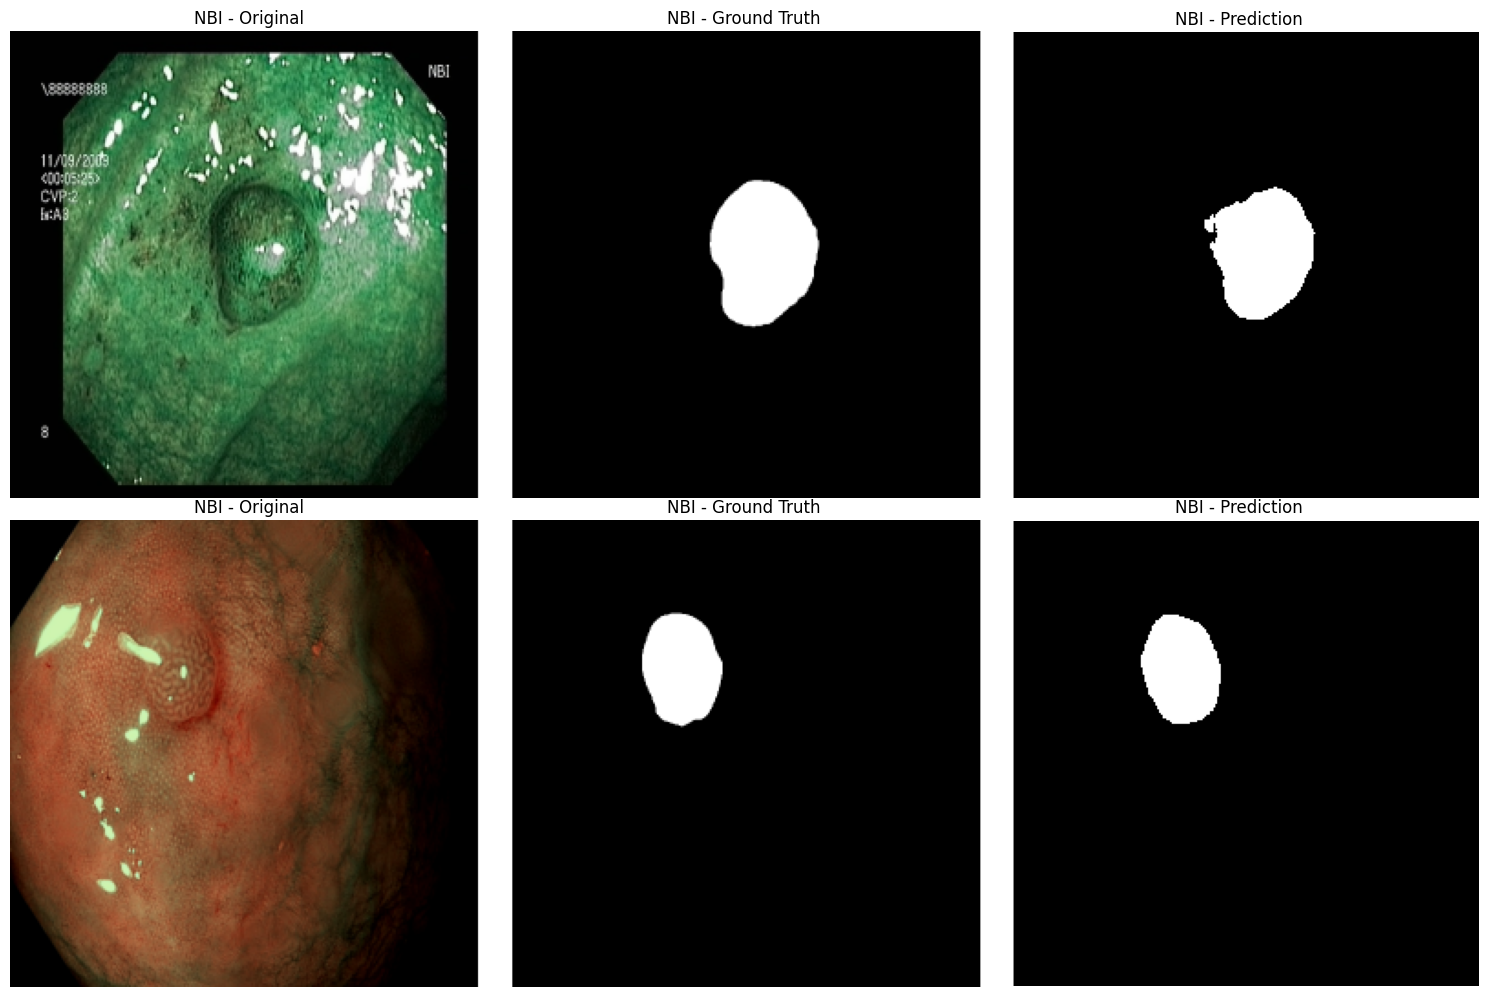


Displaying results for modality: LCI
Found 86 joint images and 86 mask images for LCI


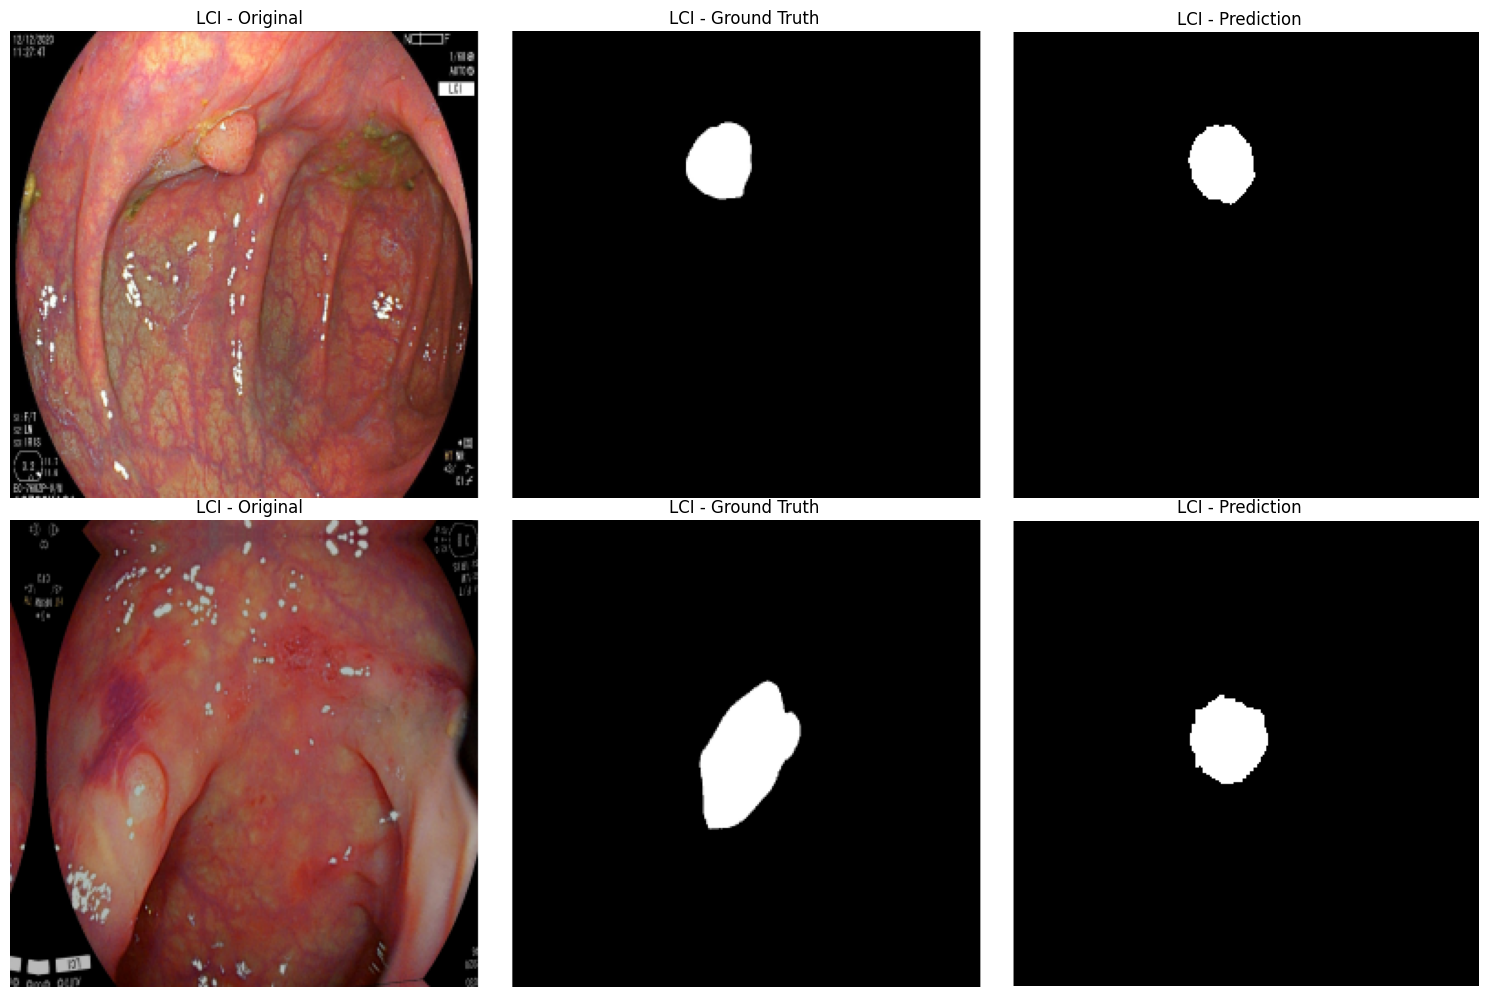


Displaying results for modality: FICE
Found 100 joint images and 100 mask images for FICE


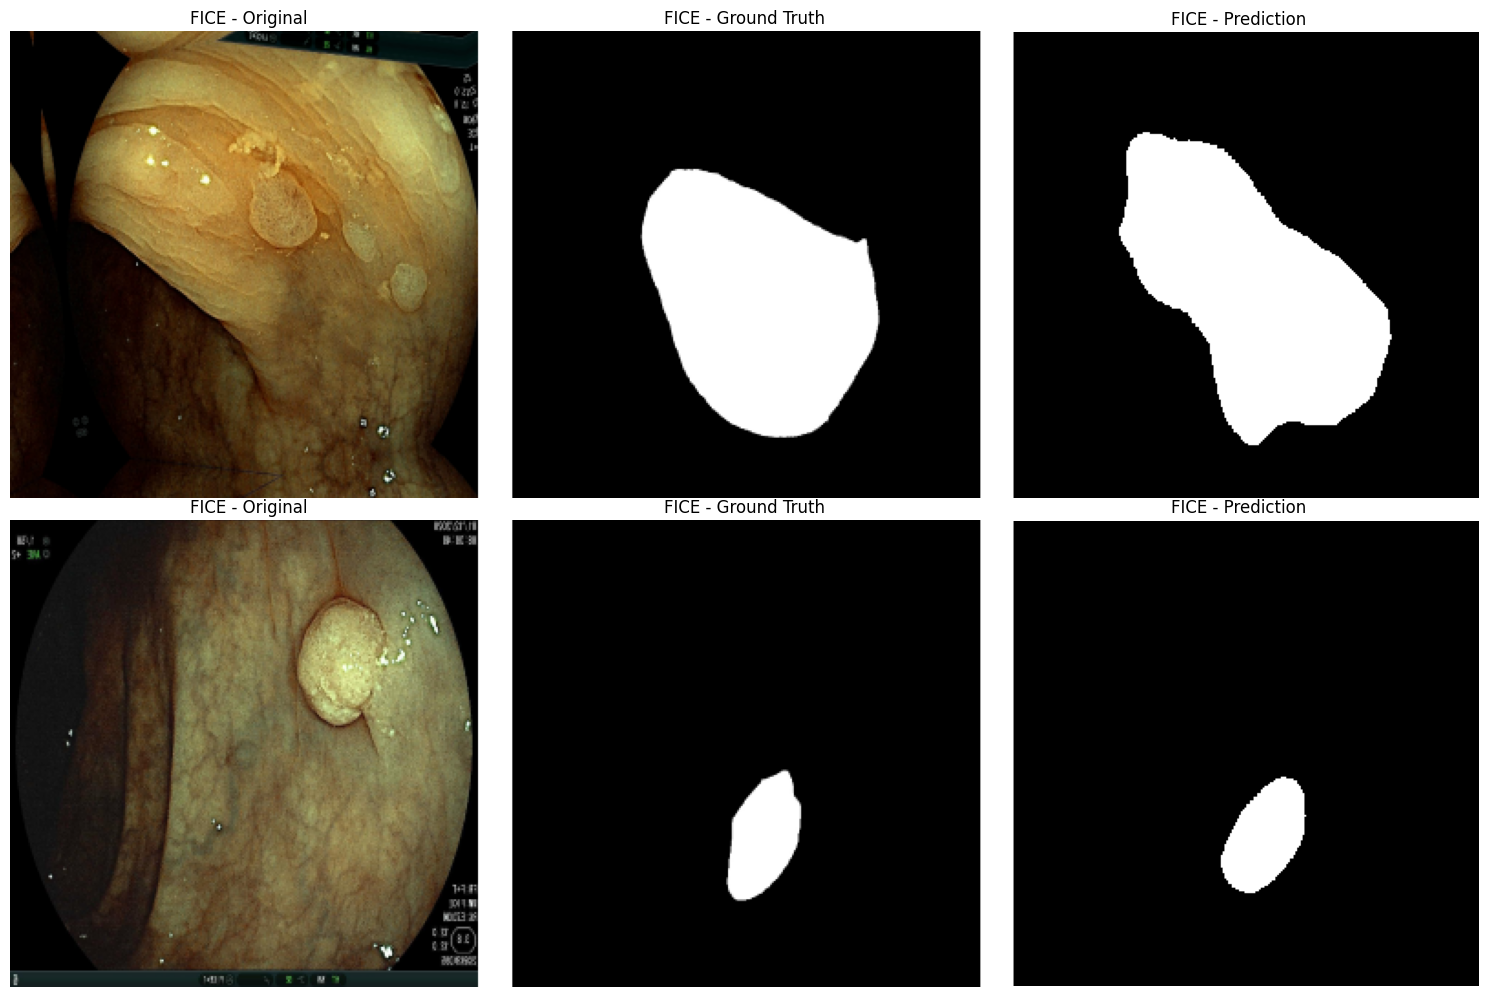


Displaying results for modality: BLI
Found 100 joint images and 100 mask images for BLI


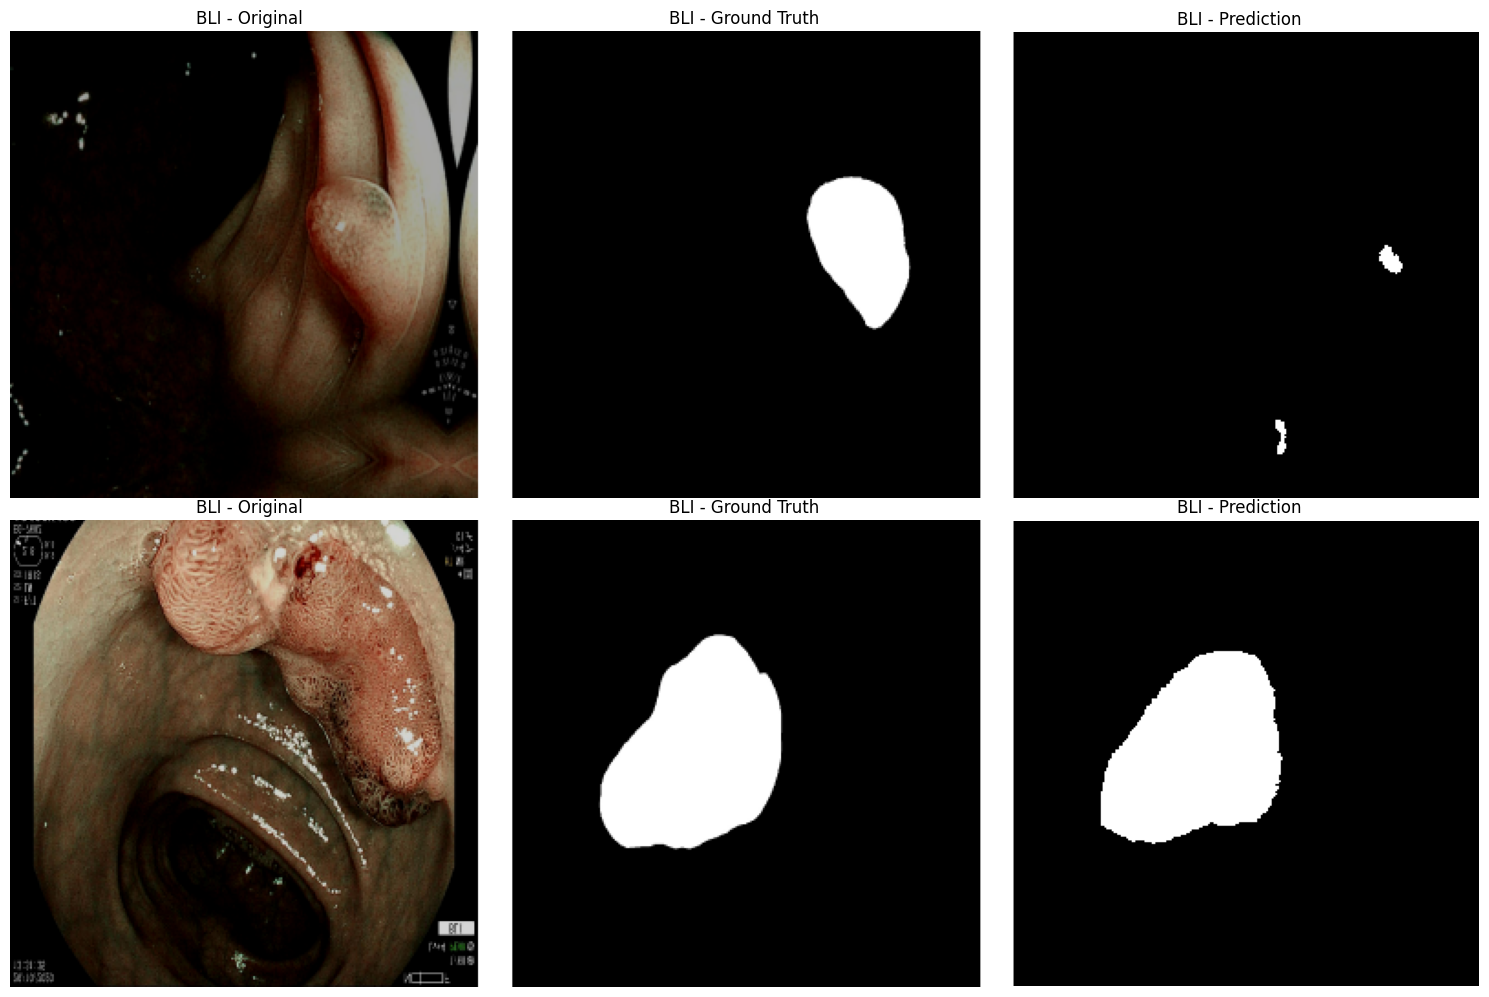

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random
from glob import glob


def display_results(modalities, base_save_path, num_images=2):

    for modality in modalities:

        print(f"\nDisplaying results for modality: {modality}")

        save_path = os.path.join(base_save_path, modality)

        mask_paths = glob(os.path.join(save_path, 'mask', '*.png'))
        joint_paths = glob(os.path.join(save_path, 'joint', '*.png'))

        print(
            f"Found {len(joint_paths)} joint images "
            f"and {len(mask_paths)} mask images for {modality}"
        )

        # Number of samples
        n = min(num_images, len(joint_paths), len(mask_paths))

        if n == 0:
            print(f"No images found for {modality}.")
            continue

        # Random samples every time
        joint_paths = random.sample(joint_paths, n)
        mask_paths = random.sample(mask_paths, n)

        plt.figure(figsize=(15, 5 * n))

        for i in range(n):

            # Read joint image
            joint_image = cv2.imread(joint_paths[i])

            if joint_image is None:
                print(f"Error reading image: {joint_paths[i]}")
                continue

            # Split joint image into 3 parts
            width = joint_image.shape[1] // 3

            original_image = joint_image[:, :width]
            ground_truth_mask = joint_image[:, width:2 * width]
            predicted_mask = joint_image[:, 2 * width:]

            # Original image
            plt.subplot(n, 3, i * 3 + 1)
            plt.imshow(
                cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            )
            plt.title(f"{modality} - Original")
            plt.axis('off')

            # Ground truth
            plt.subplot(n, 3, i * 3 + 2)
            plt.imshow(
                cv2.cvtColor(ground_truth_mask, cv2.COLOR_BGR2RGB)
            )
            plt.title(f"{modality} - Ground Truth")
            plt.axis('off')

            # Prediction
            plt.subplot(n, 3, i * 3 + 3)
            plt.imshow(
                cv2.cvtColor(predicted_mask, cv2.COLOR_BGR2RGB)
            )
            plt.title(f"{modality} - Prediction")
            plt.axis('off')

        plt.tight_layout()
        plt.show()


# Example
modalities = ["NBI", "LCI", "FICE", "BLI"]

base_save_path = "/kaggle/working/results"

display_results(
    modalities,
    base_save_path,
    num_images=2
)